In [5]:
import numpy as np
import matplotlib.pyplot as plt
from model_ranking.utils import (
    load_h5,
    get_roi_slice
)

In [6]:
E_gt_path = "/scratch/talks/data/EPFL/test.h5"
E_gt = load_h5(E_gt_path, "labels")
E_raw = load_h5(E_gt_path, "raw")

# Rmito Residual

In [3]:
RtoE_Res_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_Res_pred = load_h5(RtoE_Res_path, "predictions")
RtoE_Res_patch_positions = load_h5(RtoE_Res_path, "patch_index")
RtoE_Res_f1_scores = load_h5(RtoE_Res_path, "hard_f1")

In [9]:
RtoE_Res_p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/gauss_a01-012/predictions/test_predictions.h5"
consis_scores = load_h5(RtoE_Res_p_path, "EI_consis")

In [13]:
ms_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/gauss_a01-012/predictions/metric_summary_full.h5"
sum_consis_scores = load_h5(ms_path, "EI_consis_median")
print(sum_consis_scores)

0.46514702


In [12]:
np.nanmedian(consis_scores)

0.46514702

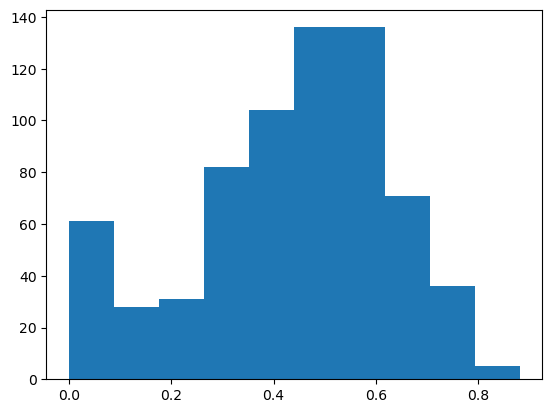

In [15]:
plt.hist(consis_scores.flatten())
plt.show()

In [14]:
np.sum(np.isnan(consis_scores))

60

In [5]:
np.median(RtoE_Res_f1_scores[:,1])

0.03238437

In [7]:
RtoE_Res_f1_scores[:, 1].max()
ids = np.where((RtoE_Res_f1_scores[:, 1] >= 0.05) & (RtoE_Res_f1_scores[:, 1] < 0.06))[0]
print(len(ids))

38


In [6]:
RtoE_Res_f1_scores[:, 1].max()
ids = np.where((RtoE_Res_f1_scores[:, 1] >= 0.03) & (RtoE_Res_f1_scores[:, 1] < 0.04))[0]
print(len(ids))

26


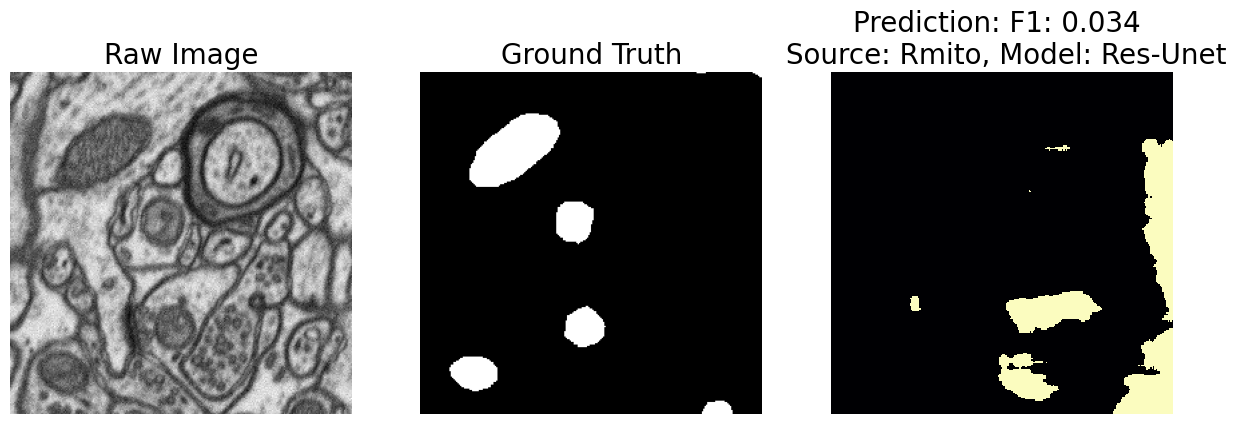

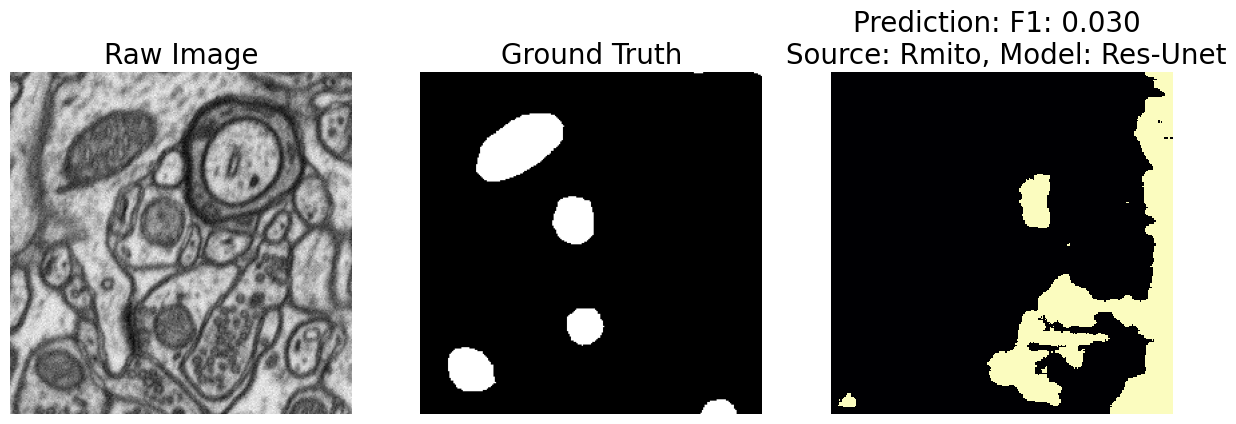

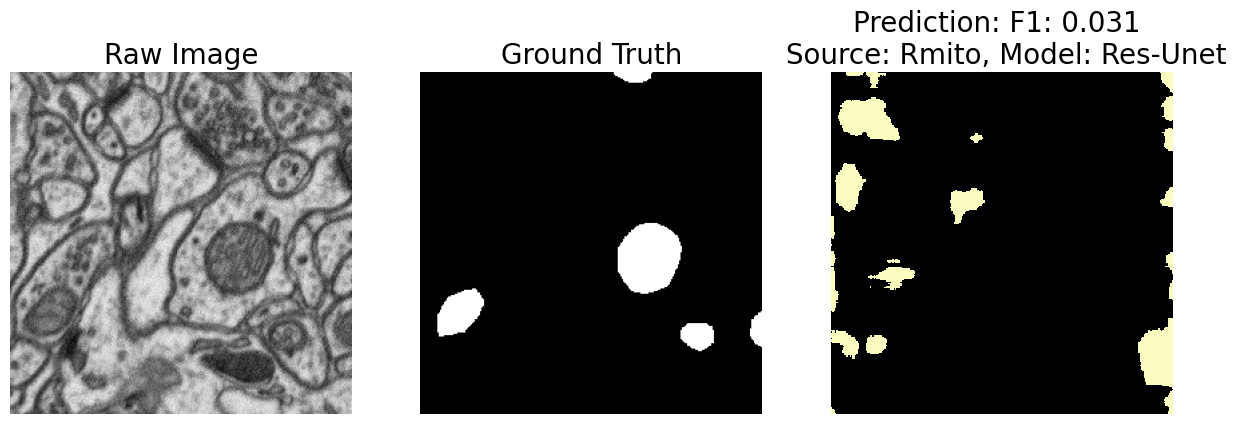

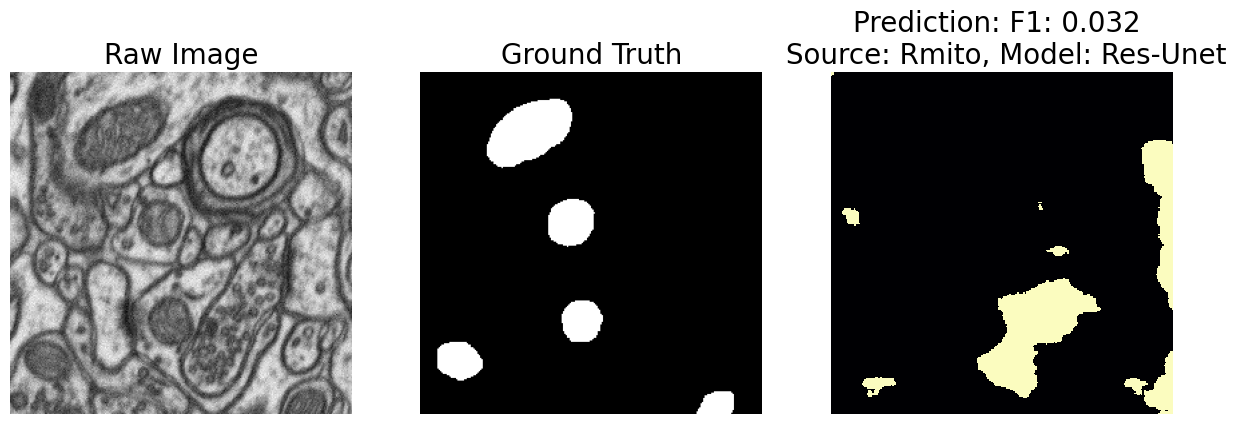

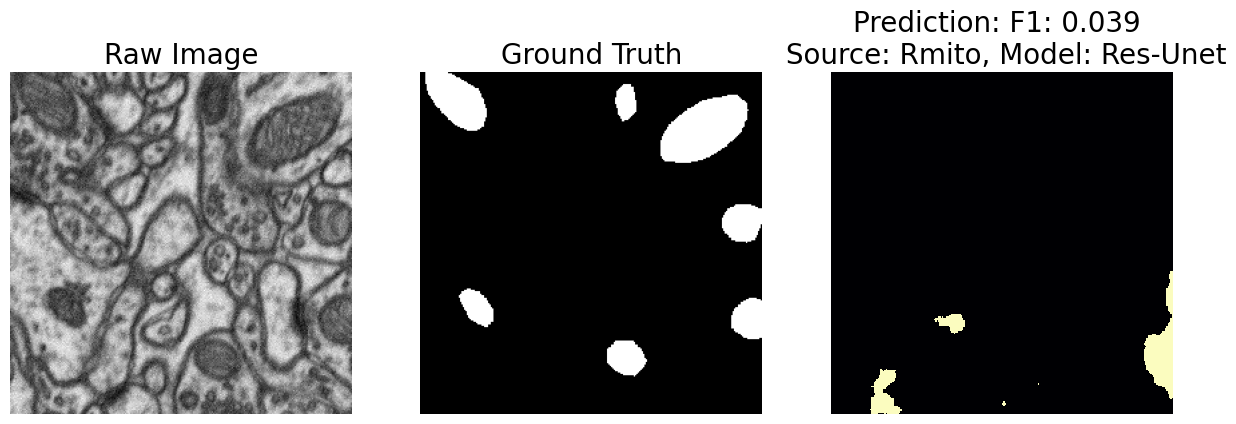

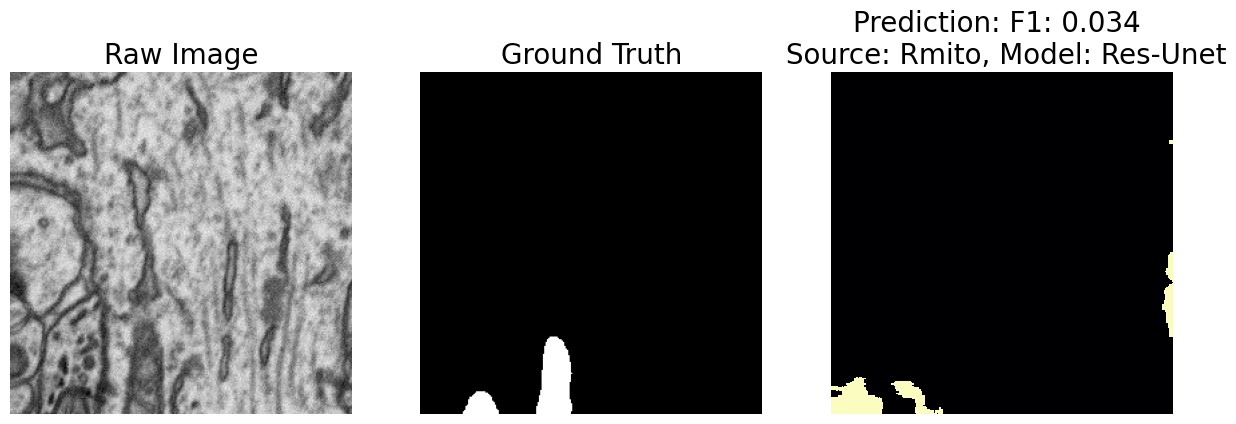

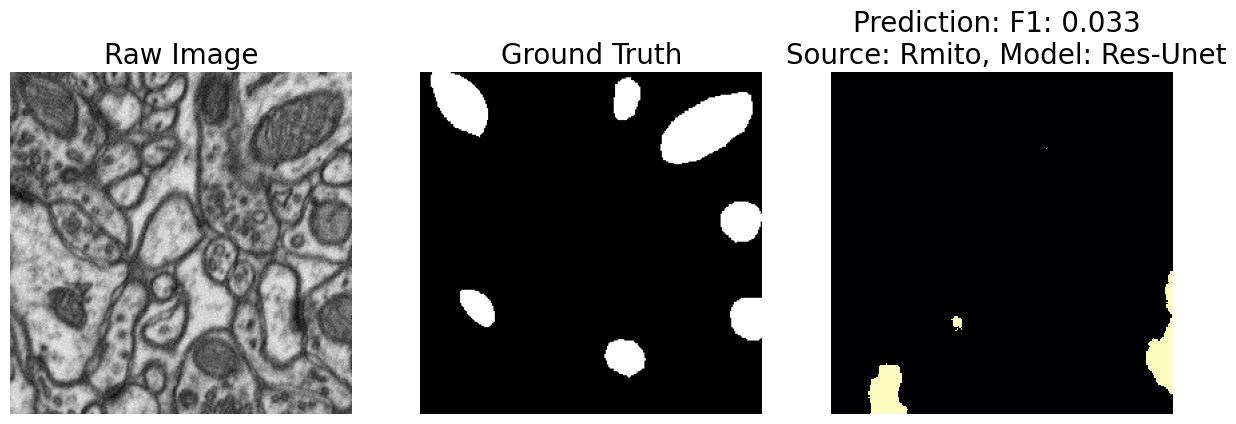

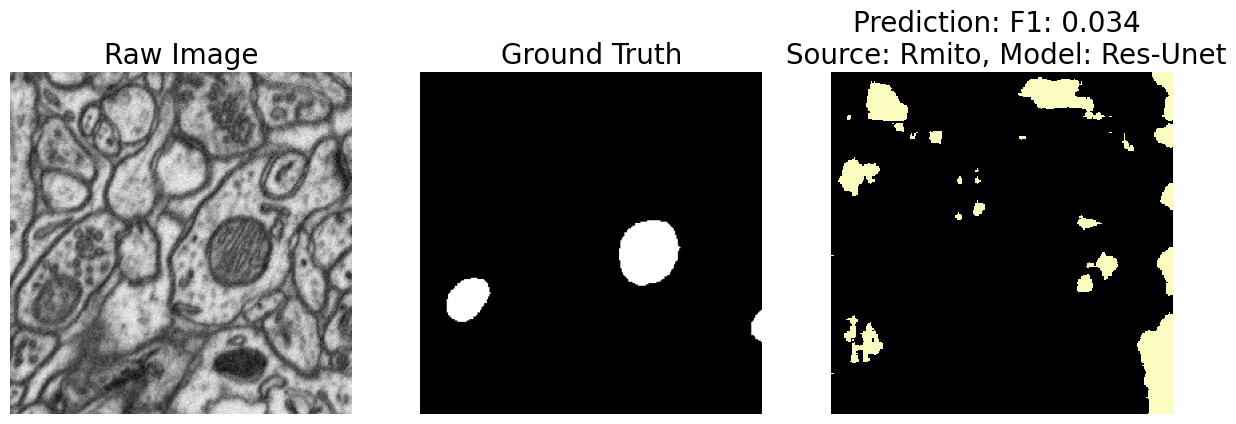

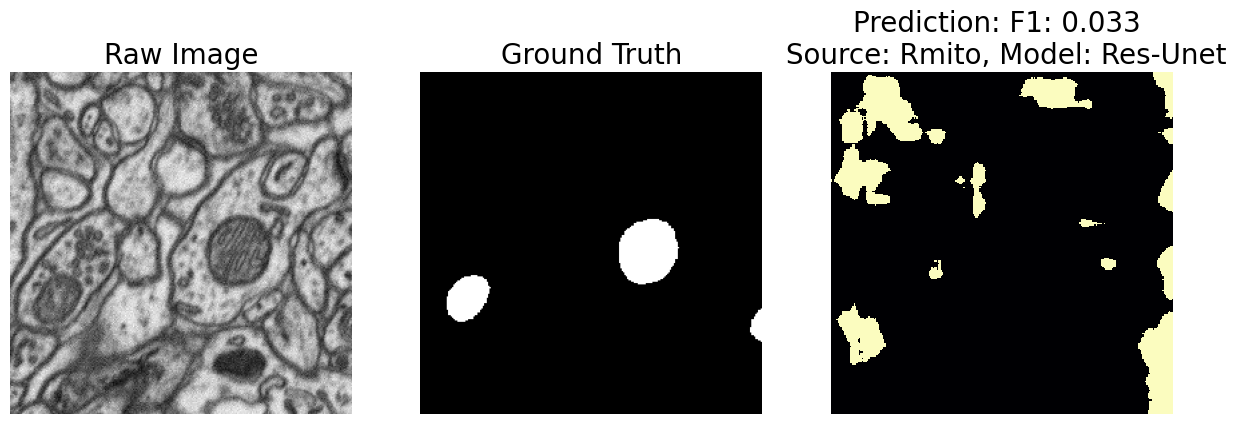

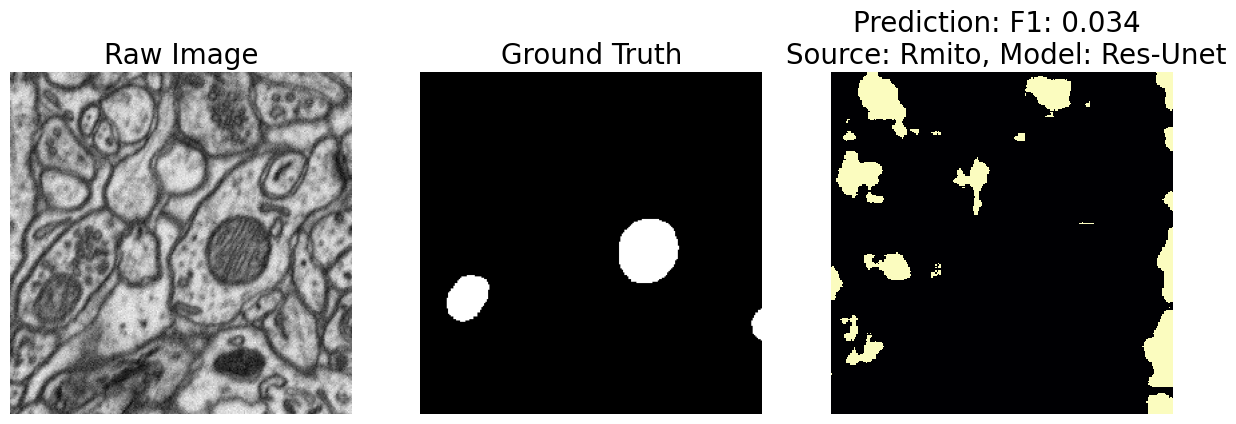

In [8]:
font_size = 20
for i, idx in enumerate(ids[:10]):
    _ , axs = plt.subplots(1, 3, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_Res_patch_positions[idx])
    axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    axs[0].set_title(f"Raw Image", fontsize=font_size)
    axs[0].axis('off')
    axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    axs[1].set_title(f"Ground Truth", fontsize=font_size)
    axs[1].axis('off')
    axs[2].imshow(RtoE_Res_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs[2].set_title(f"Prediction: F1: {RtoE_Res_f1_scores[idx, 1]:.3f} \n Source: Rmito, Model: Res-Unet", fontsize=font_size)
    axs[2].axis('off')
plt.show()

# RtoE_Res check

In [7]:
RtoE_Res_path = "/g/kreshuk/talks/model_ranking/scripts/prediction_consistency/checks/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/none/predictions/test_predictions.h5"
RtoE_Res_pred = load_h5(RtoE_Res_path, "predictions")
RtoE_Res_patch_positions = load_h5(RtoE_Res_path, "patch_index")
RtoE_Res_f1_scores = load_h5(RtoE_Res_path, "hard_f1")

In [8]:
ms_path = "/g/kreshuk/talks/model_ranking/scripts/prediction_consistency/checks/Rmito_to_EPFL_gap/consistency/P_full/Rm_model_Res1/norm_Normalize/gauss_a01-012/metric_summary_full.h5"
sum_consis_scores = load_h5(ms_path, "EI_consis_median")
print(sum_consis_scores)

0.46000752


In [9]:
np.median(RtoE_Res_f1_scores[:,1])

0.03226772

In [10]:
RtoE_Res_f1_scores[:, 1].max()
ids = np.where((RtoE_Res_f1_scores[:, 1] >= 0.05) & (RtoE_Res_f1_scores[:, 1] < 0.06))[0]
print(len(ids))

37


In [11]:
RtoE_Res_f1_scores[:, 1].max()
ids = np.where((RtoE_Res_f1_scores[:, 1] >= 0.03) & (RtoE_Res_f1_scores[:, 1] < 0.04))[0]
print(len(ids))

26


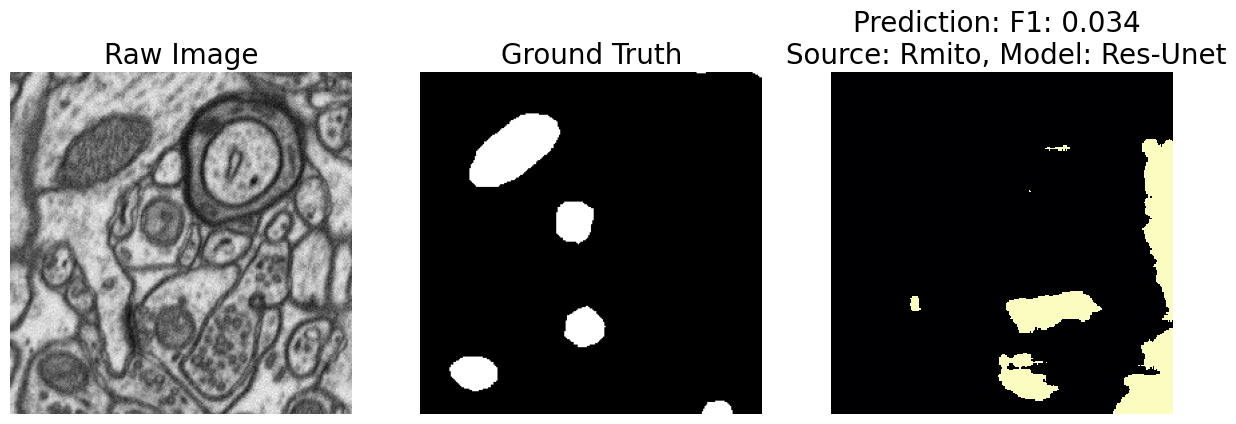

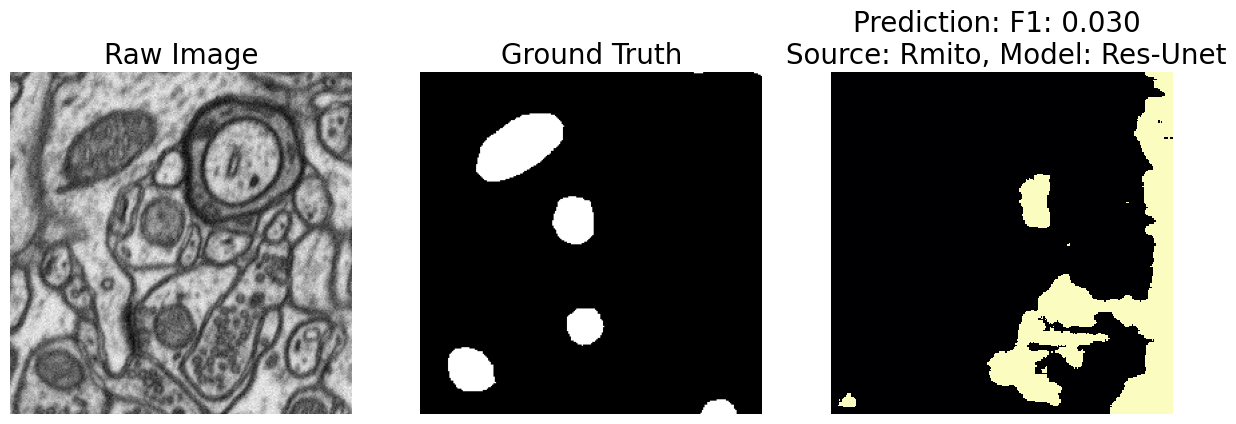

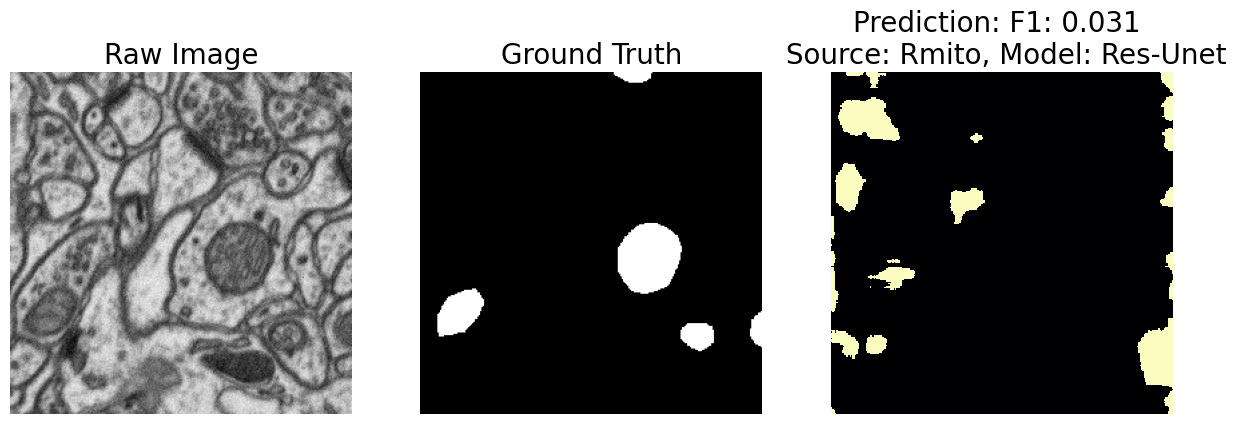

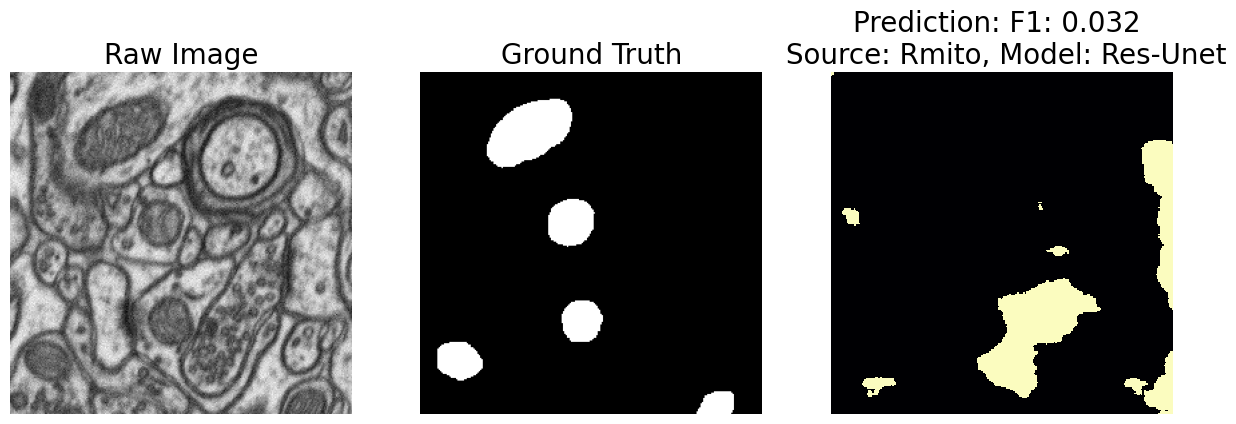

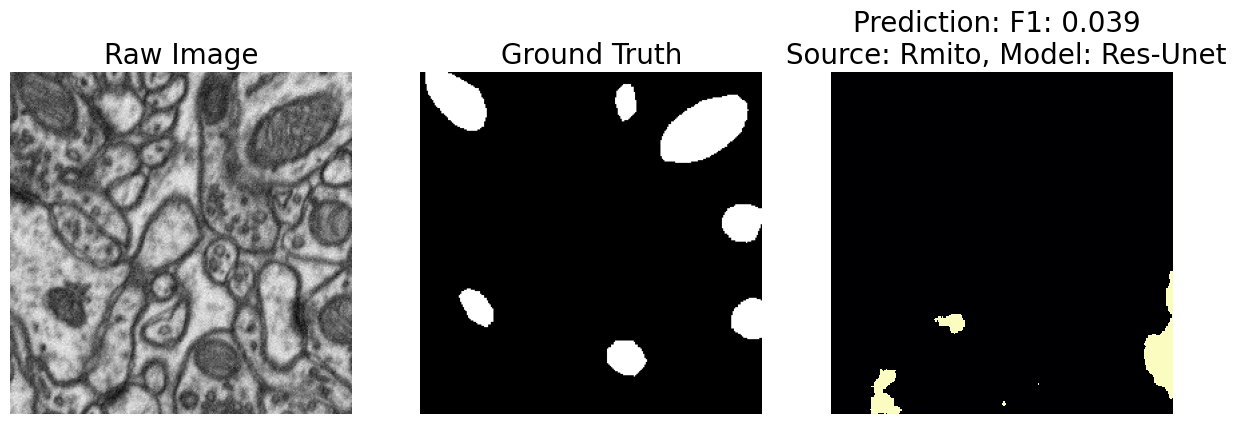

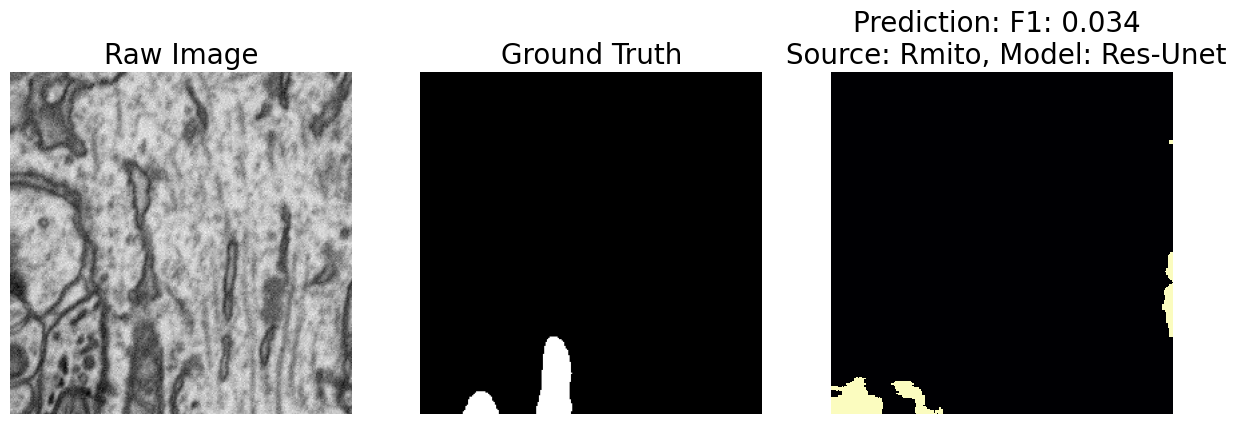

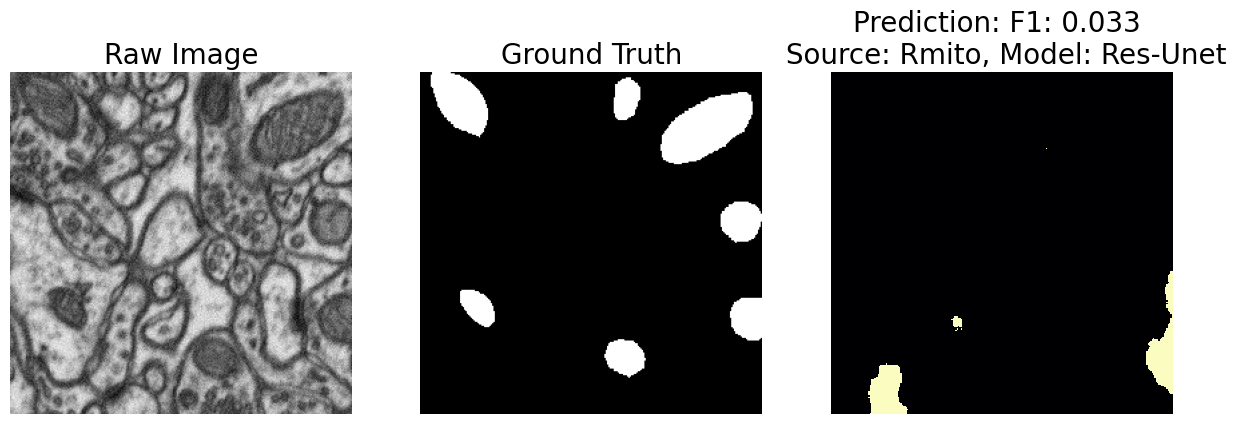

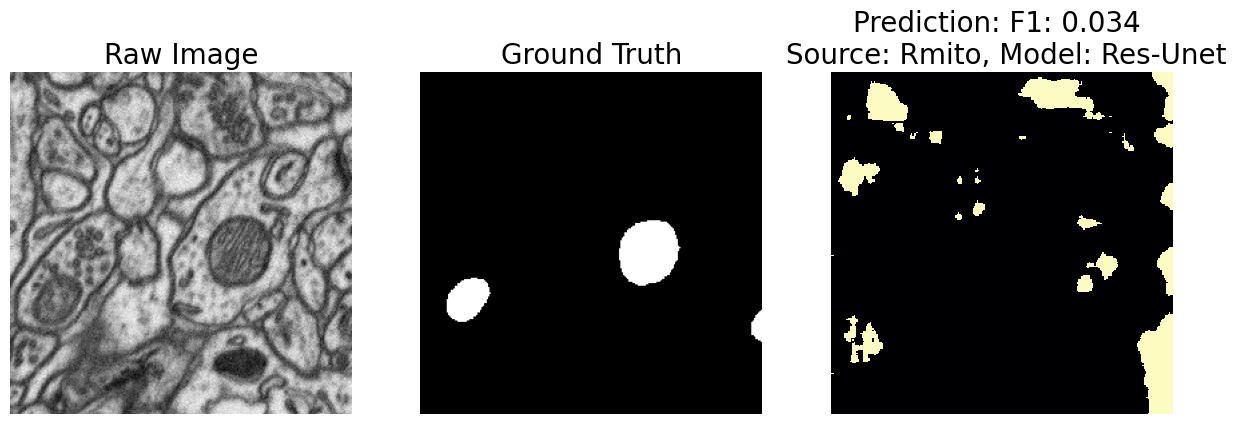

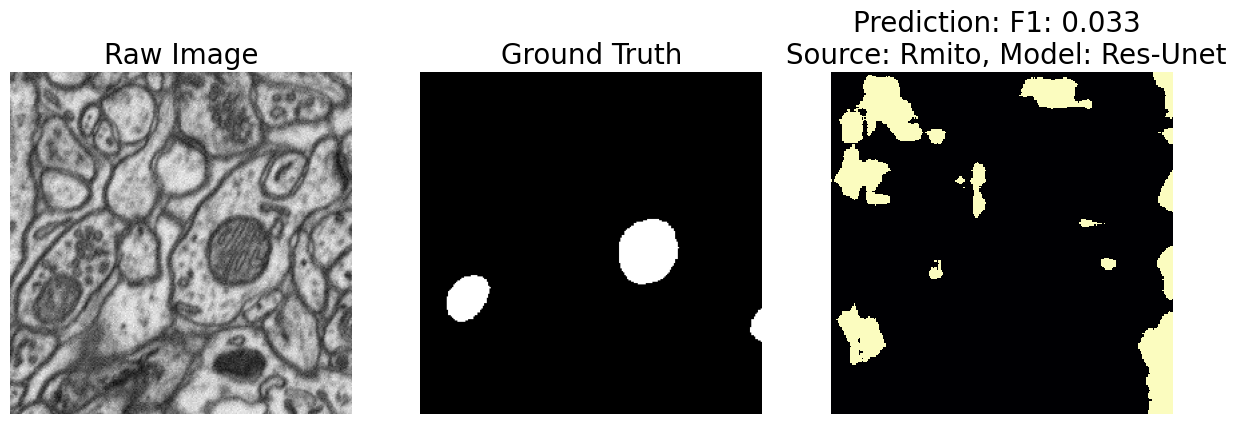

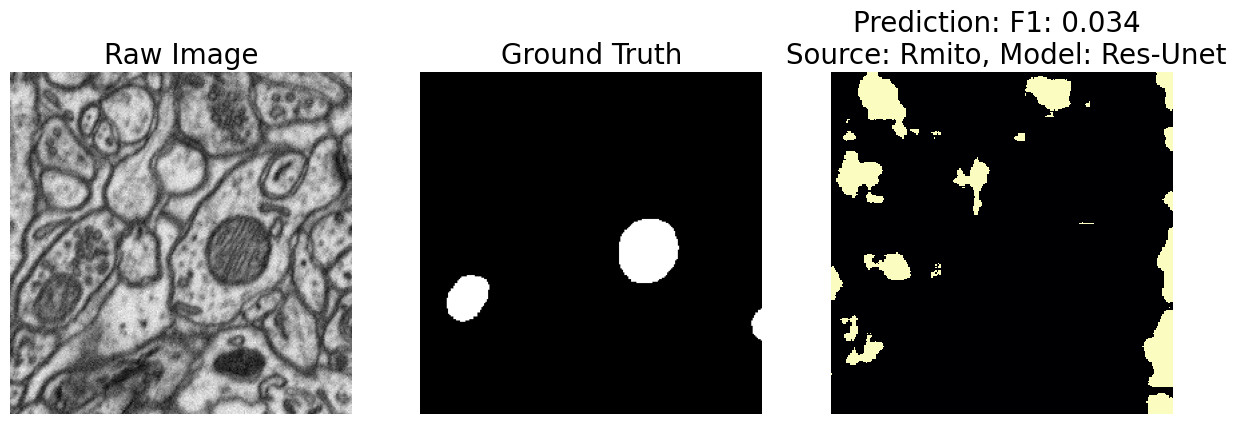

In [10]:
font_size = 20
for i, idx in enumerate(ids[:10]):
    _ , axs = plt.subplots(1, 3, figsize=(15, 5))
    patch_slice = get_roi_slice(RtoE_Res_patch_positions[idx])
    axs[0].imshow(E_raw[patch_slice].squeeze(), cmap="gray")
    axs[0].set_title(f"Raw Image", fontsize=font_size)
    axs[0].axis('off')
    axs[1].imshow(E_gt[patch_slice].squeeze(), cmap="gray")
    axs[1].set_title(f"Ground Truth", fontsize=font_size)
    axs[1].axis('off')
    axs[2].imshow(RtoE_Res_pred[idx].squeeze()> 0.5, cmap="magma", interpolation="nearest")
    axs[2].set_title(f"Prediction: F1: {RtoE_Res_f1_scores[idx, 1]:.3f} \n Source: Rmito, Model: Res-Unet", fontsize=font_size)
    axs[2].axis('off')
plt.show()

# Direct prediction

In [1]:
import torch
import matplotlib.pyplot as plt
from pytorch3dunet.unet3d.model import UNet2D, ResidualUNet2D

/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


INFO: P [MainThread] 2025-11-12 09:19:06,280 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [32]:
from typing import Any, Dict
from torch.utils.data import ConcatDataset, DataLoader
from model_ranking import (
    semantic_loaders_type,
    loader_classes,
    Pytorch3DUnetTrainLoaderConfig,
    Pytorch3DUnetTestLoaderConfig,
    Pytorch3DUnetLoaderMetaConfig,
    Pytorch3DUnetSliceBuilderConfig,
)


def get_datasets(
    config: semantic_loaders_type,
):
    # get dataset class
    dataset_cls_str = config.dataset
    dataset_class = loader_classes(dataset_cls_str)
    datasets = dataset_class.create_datasets(config.model_dump(), phase="test")
    return datasets

def initialise_target_datasets(# pyright: ignore
    loader_config: Pytorch3DUnetLoaderMetaConfig,
):

    target_dataset_cfg = loader_config.create_config(
        output_dir="/g/kreshuk/talks/model_ranking/scripts/prediction_consistency/checks",
        data_base_path="/scratch/talks/data",
        phase="test",
    )
    assert isinstance(
        target_dataset_cfg,
        (
            Pytorch3DUnetTrainLoaderConfig,
            Pytorch3DUnetTestLoaderConfig,

        ),
    ), f"Expected semantic loader config type, got {type(target_dataset_cfg).__name__}"
    datasets = get_datasets(target_dataset_cfg)
    target_dataset  = ConcatDataset(datasets) # pyright: ignore
    target_dataloader = DataLoader(# pyright: ignore
        target_dataset,# pyright: ignore
        batch_size=target_dataset_cfg.batch_size,
        shuffle=False,
        pin_memory=True,
        num_workers=target_dataset_cfg.num_workers,
    )

    return target_dataset, target_dataloader# pyright: ignore

In [33]:
EPFL_loader_cfg: Pytorch3DUnetLoaderMetaConfig = Pytorch3DUnetLoaderMetaConfig(
        dataset="StandardHDF5Dataset",
        batch_size=10,
        num_workers=8,
        raw_internal_path="raw",
        label_internal_path="labels",
        global_normalization=True,
        #global_normalization=False,
        global_percentiles=None,
        file_paths=("/EPFL/test.h5",),
        roi=None,
        transformer={
            "raw": [
                {"name": "Normalize"},
                {"name": "ToTensor", "expand_dims": True},
            ],
            # "label": [
            #     {"name": "ToTensor", "expand_dims": True},
            # ],
        },
        slice_builder=Pytorch3DUnetSliceBuilderConfig(
            name="SliceBuilder",
            patch_shape=(1, 480, 640),
            stride_shape=(1, 480, 640),
            halo_shape=(0, 96, 96),
            # patch_shape=(1, 256, 256),
            # stride_shape=(1, 256, 256),
            # halo_shape=(0, 32, 32),
        ),
    )

dataset, dataloader = initialise_target_datasets(EPFL_loader_cfg)

2025-11-12 09:39:16,683 [MainThread] INFO HDF5Dataset - Loading test set from: /scratch/talks/data/EPFL/test.h5...
2025-11-12 09:39:16,686 [MainThread] INFO HDF5Dataset - Auto-calculated padding: [0, 0, 0] for patch_shape: (1, 480, 640) and volume_shape: (125, 480, 640)
2025-11-12 09:39:16,686 [MainThread] INFO HDF5Dataset - Calculating mean and std of the raw data...
Global mean: 0.5599145293235779, global std: 0.11937469989061356
2025-11-12 09:39:16,909 [MainThread] INFO Dataset - Slice builder config: {'name': 'SliceBuilder', 'patch_shape': (1, 480, 640), 'stride_shape': (1, 480, 640), 'halo_shape': (0, 96, 96)}
2025-11-12 09:39:16,910 [MainThread] INFO HDF5Dataset - Number of patches: 125


In [34]:
print(len(dataset))

125


torch.Size([1, 1, 672, 832])


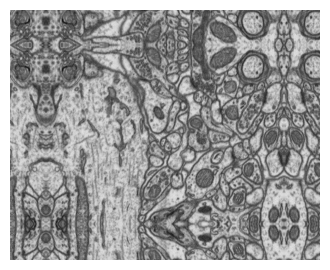

In [40]:
raw, _ = dataset[38]
print(raw.shape)
_, axs = plt.subplots(1, 1, figsize=(4, 8))
axs.imshow(raw.numpy().squeeze(), cmap='grey')
axs.axis('off')
# axs[1].imshow(label.numpy().squeeze(), cmap='grey')
# axs[1].axis('off')
plt.show()

# Rm_model_Res1

In [41]:
RtoE_model_ckpt_path = "/g/kreshuk/talks/segmentation_ModelSelection/experiments/Rmito/BatchNorm/Rm_model_Res1/best_checkpoint.pytorch"
# Load model checkpoint
model_config: Dict[str, Any] = {
    'name': 'ResidualUNet2D',
    'in_channels': 1,
    'out_channels': 1,
    'layer_order': 'bcr',
    'f_maps': 64,
    'final_sigmoid': True,
    'is_segmentation': True
}

# Initialize model
model = ResidualUNet2D(**model_config)

# Load model weights
_ = model.load_state_dict(torch.load(RtoE_model_ckpt_path, map_location='cpu')['model_state_dict'])
_ = model.eval()

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


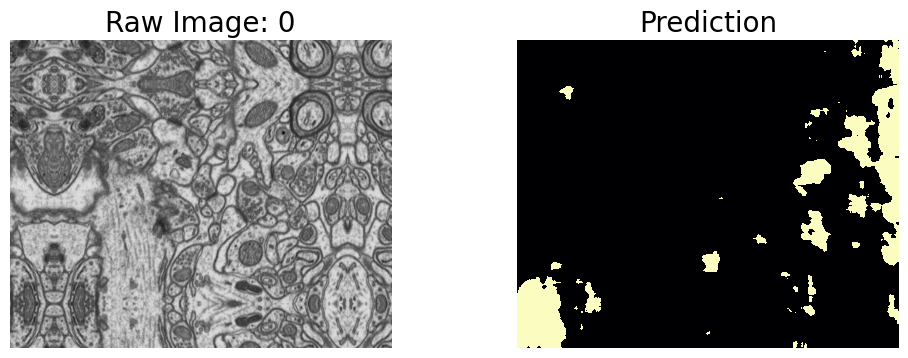

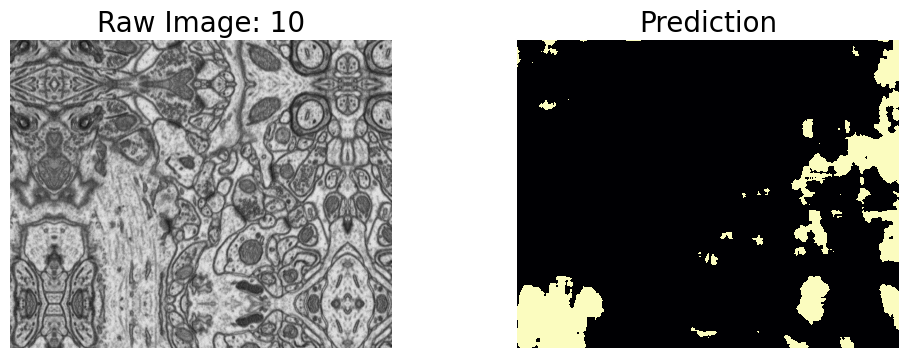

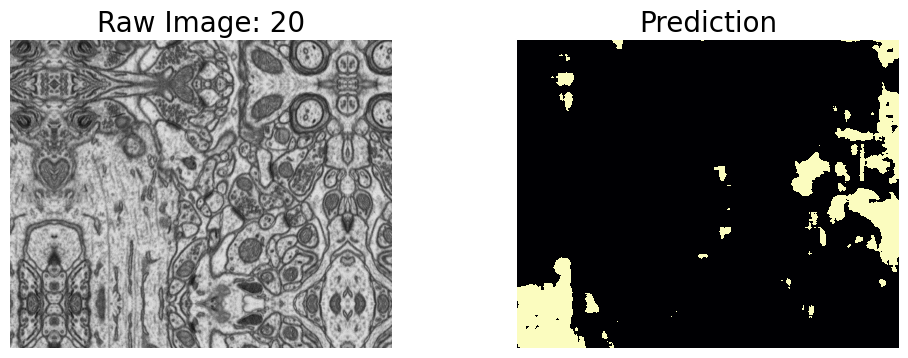

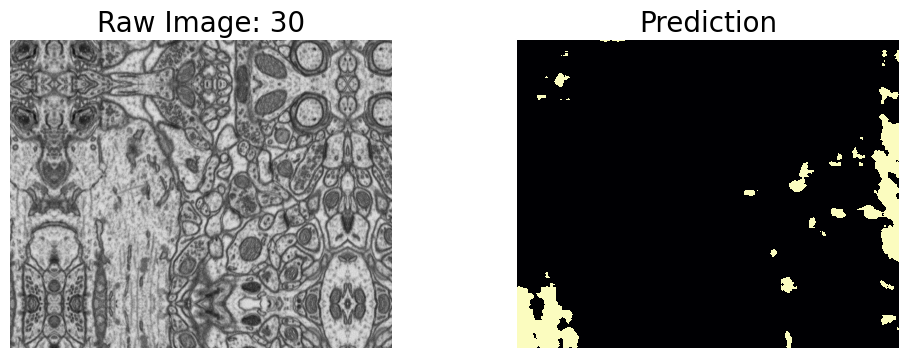

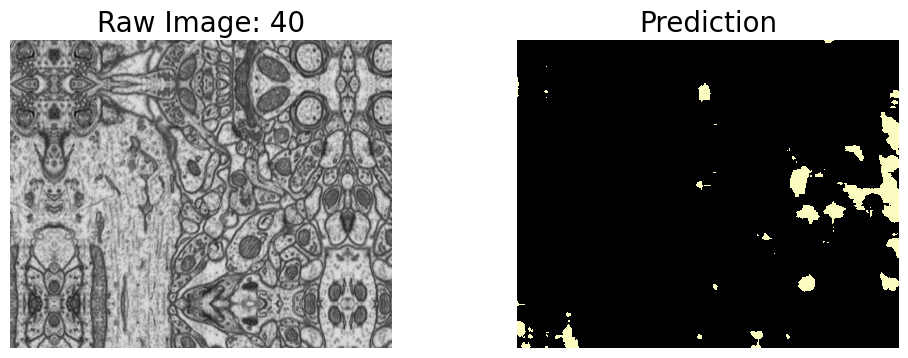

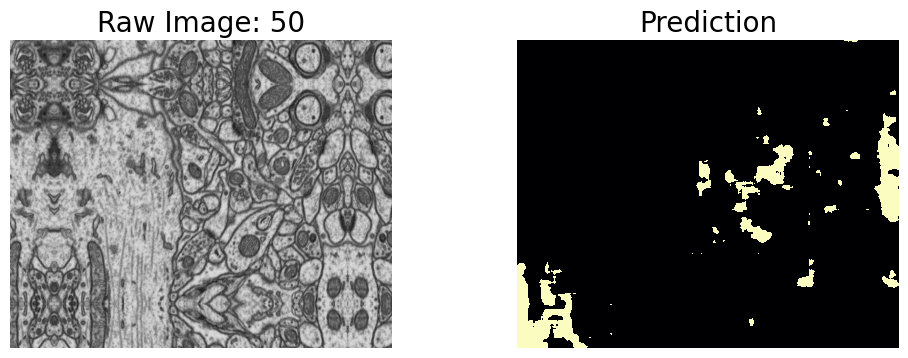

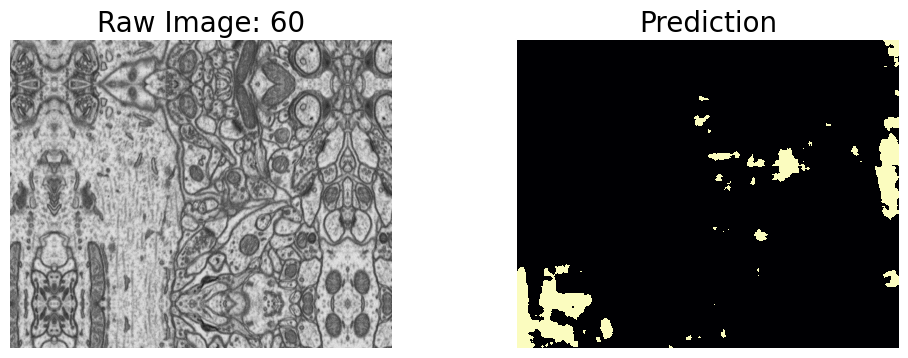

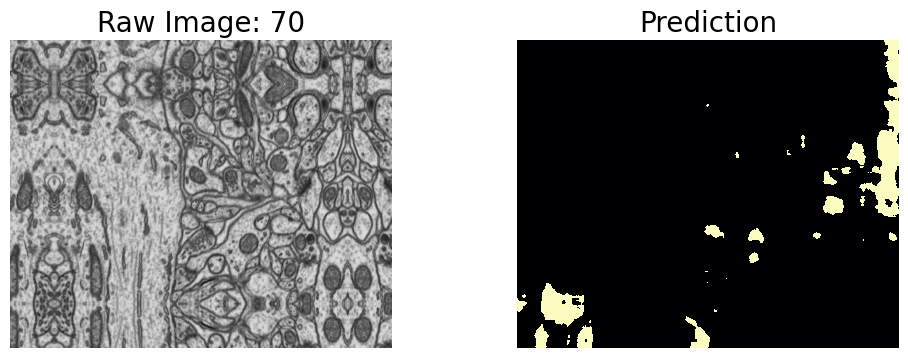

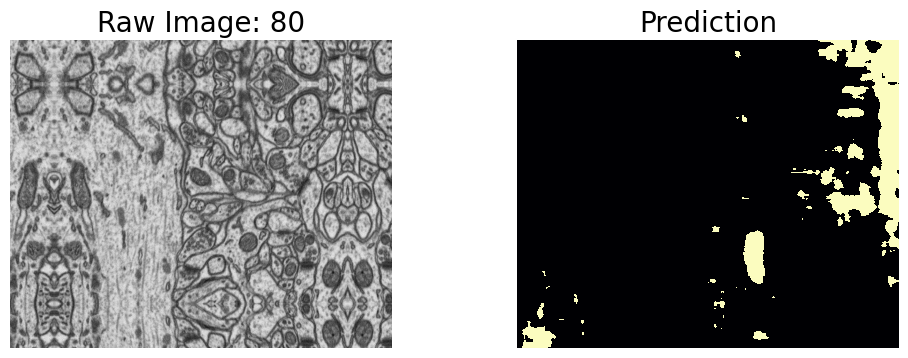

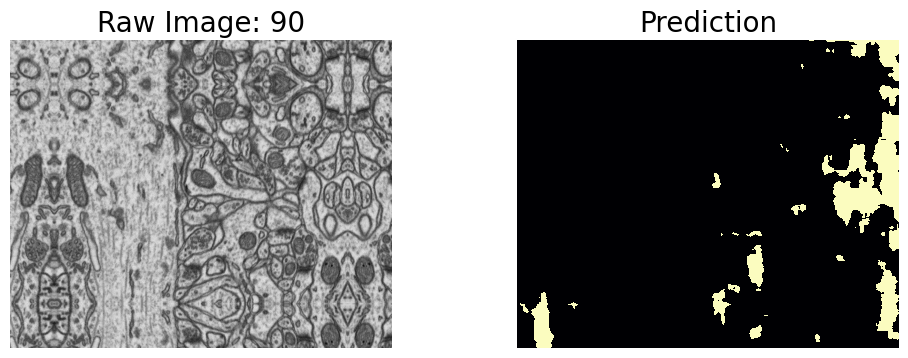

In [42]:
with torch.no_grad():
    for i in range(0, 100, 10):
        raw, _ = dataset[i]
        pred = model(raw) > 0.5
        # print(pred.shape)
        _, axs = plt.subplots(1, 2, figsize=(12, 4))
        axs[0].imshow(raw.numpy().squeeze(), cmap='gray')
        axs[0].set_title(f"Raw Image: {i}", fontsize=20)
        axs[0].axis('off')
        axs[1].imshow(pred.numpy().squeeze(), cmap='magma', interpolation='nearest')
        axs[1].set_title("Prediction", fontsize=20)
        axs[1].axis('off')
        # axs[2].imshow(pred.numpy().squeeze(), cmap='magma', interpolation='nearest')
        # axs[2].set_title("Prediction", fontsize=20)
        # axs[2].axis('off')
        plt.show()


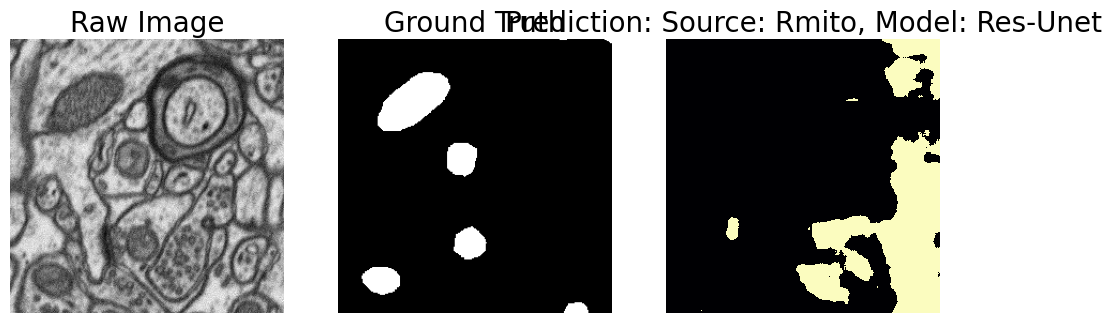

In [ ]:
_, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(raw.numpy().squeeze(), cmap='gray')
axs[0].set_title("Raw Image", fontsize=20)
axs[0].axis('off')
axs[1].imshow(label.numpy().squeeze(), cmap='gray')
axs[1].set_title("Ground Truth", fontsize=20)
axs[1].axis('off')
axs[2].imshow(pred.numpy().squeeze(), cmap='magma', interpolation='nearest')
axs[2].set_title("Prediction: Source: Rmito, Model: Res-Unet", fontsize=20)
axs[2].axis('off')
plt.show()
